# Week 8 Problem Set

## Homework

In [1]:
%load_ext nb_mypy
%nb_mypy Off

Version 1.0.6


In [2]:
from typing import TypeAlias
from typing import Optional, Any, Callable, Iterator, Iterable, cast
from collections.abc import Sequence
from __future__ import annotations

Number: TypeAlias = int | float

**HW1.** *Comments:* Write a state machine whose inputs are the characters of a string. The string contains the code for a computer program. The output of the state machine are either:
- the input character if it is part of a comment, or
- `None`, otherwise.

Comment starts with a `#` character and continue to the end of the current line. If you want to create a string that contains a new line character, you can use `\n`.

For example,
```
inpstr = "def func(x): # comment\n    return 1"
m = CommentsSM()
print(m.transduce(inpstr))
```

The expected output is:
```
[None, None, None, None, None, None, None, None, None, None, None, None, None, "#", " ", "c", "o", "m", "m", "e", "n", "t", None, None, None, None, None, None, None, None, None, None, None, None, None]
```

You should start by drawing a state transition diagram indicating the states and what inputs cause transition to which other states. Use the test case above to determine if your state transition diagram is correct. You should begin writing your program only when you are confident that your diagram is correct. 

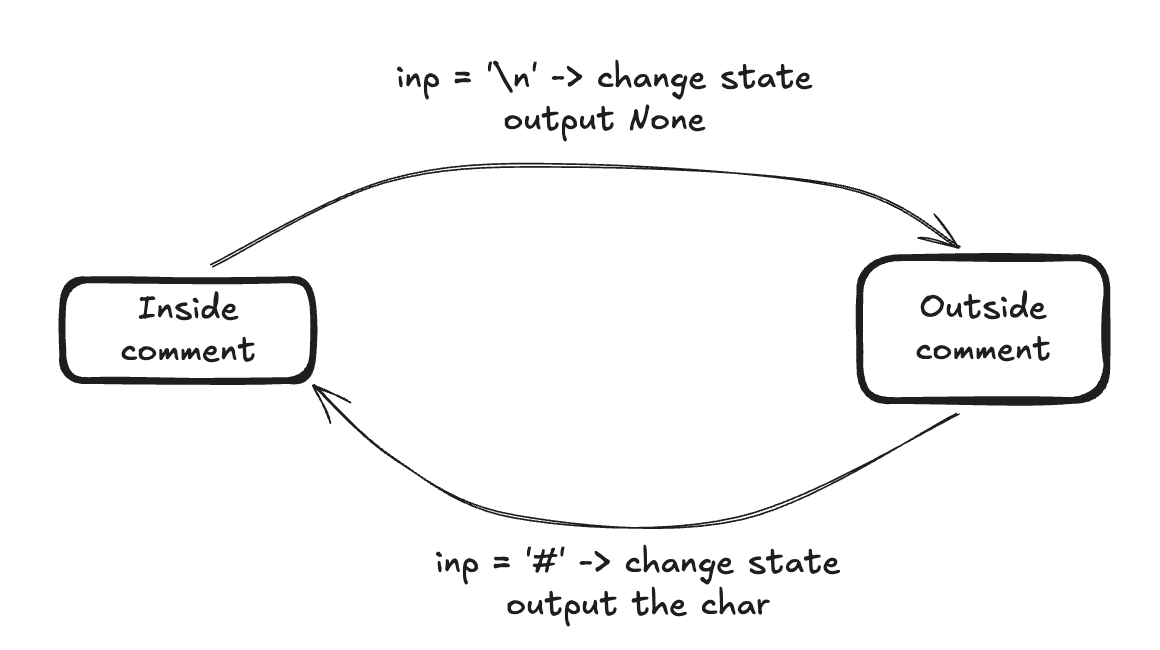

In [3]:
# show the state transition diagram I make
from IPython.display import Image, display
display(Image(filename='./week-08-diagrams/HW-CS1.png'))

In [4]:
from abc import ABC, abstractmethod

class StateMachine(ABC):
    
    def start(self) -> None:
        self.state = self.start_state

    def step(self, inp: Any) -> Any:
        next_state, current_output = self.get_next_values(self.state, inp)
        self.state = next_state
        
        return current_output
        
    def transduce(self, inp_list: Sequence[Any]) -> list[Any]:
        output_list = []
        self.start()
        
        for inp in inp_list:
            if self.is_done():
                break
            current_output = self.step(inp)
            output_list.append(current_output)
        
        return output_list

    @property
    @abstractmethod
    def start_state(self) -> Any:
        pass 

    @abstractmethod
    def get_next_values(self, state: Any, inp: Any) -> tuple[Any, Any]:
        pass

    def done(self, state: Any) -> bool:
        return False

    def is_done(self) -> bool:
        return self.done(self.state)

    

In [5]:
class CommentsSM(StateMachine):
    
    @property
    def start_state(self) -> str:
        return "outside comment"

    def get_next_values(self, state: str, inp: str) -> tuple[str, Optional[str]]:
        if state == "outside comment":
            if inp == '#':
                next_state = "inside comment"
                output = '#'
            else:
                next_state = "outside comment"
                output = None
        
        if state == 'inside comment':
            if inp == '\n':
                next_state = "outside comment"
                output = None
            else:
                next_state = "inside comment"
                output = inp
            
        return next_state, output

In [6]:
inpstr: str = "def func(x): # comment\n    return 1"
m: CommentsSM = CommentsSM()
out: list[Optional[str]] = m.transduce(inpstr)
assert out == [None, None, None, None, None, None, None, None, None, None, None, None, None, "#", " ", "c", "o", "m", "m", "e", "n", "t", None, None, None, None, None, None, None, None, None, None, None, None, None]

In [7]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW2.** *First Word:* Write a state machine whose inputs are the characters of a string and which outputs either:
- the input character if it is part of the first word on a line, or
- `None`, otherwise

For the purposes here, a word is any sequence of consecutive characters that does not contain spaces or end-of-line characters. In this problem, comments have no special status. This means that if the line begins with `# `, then the first word is `#`. 

For example, 
```
inpstr = "def func(x): # comment\n    return 1"
m = FirstWordSM()
print(m.transduce( inpstr))
```

The expected output is:
```
["d", "e", "f", None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, "r", "e", "t", "u", "r", "n", None, None]
```

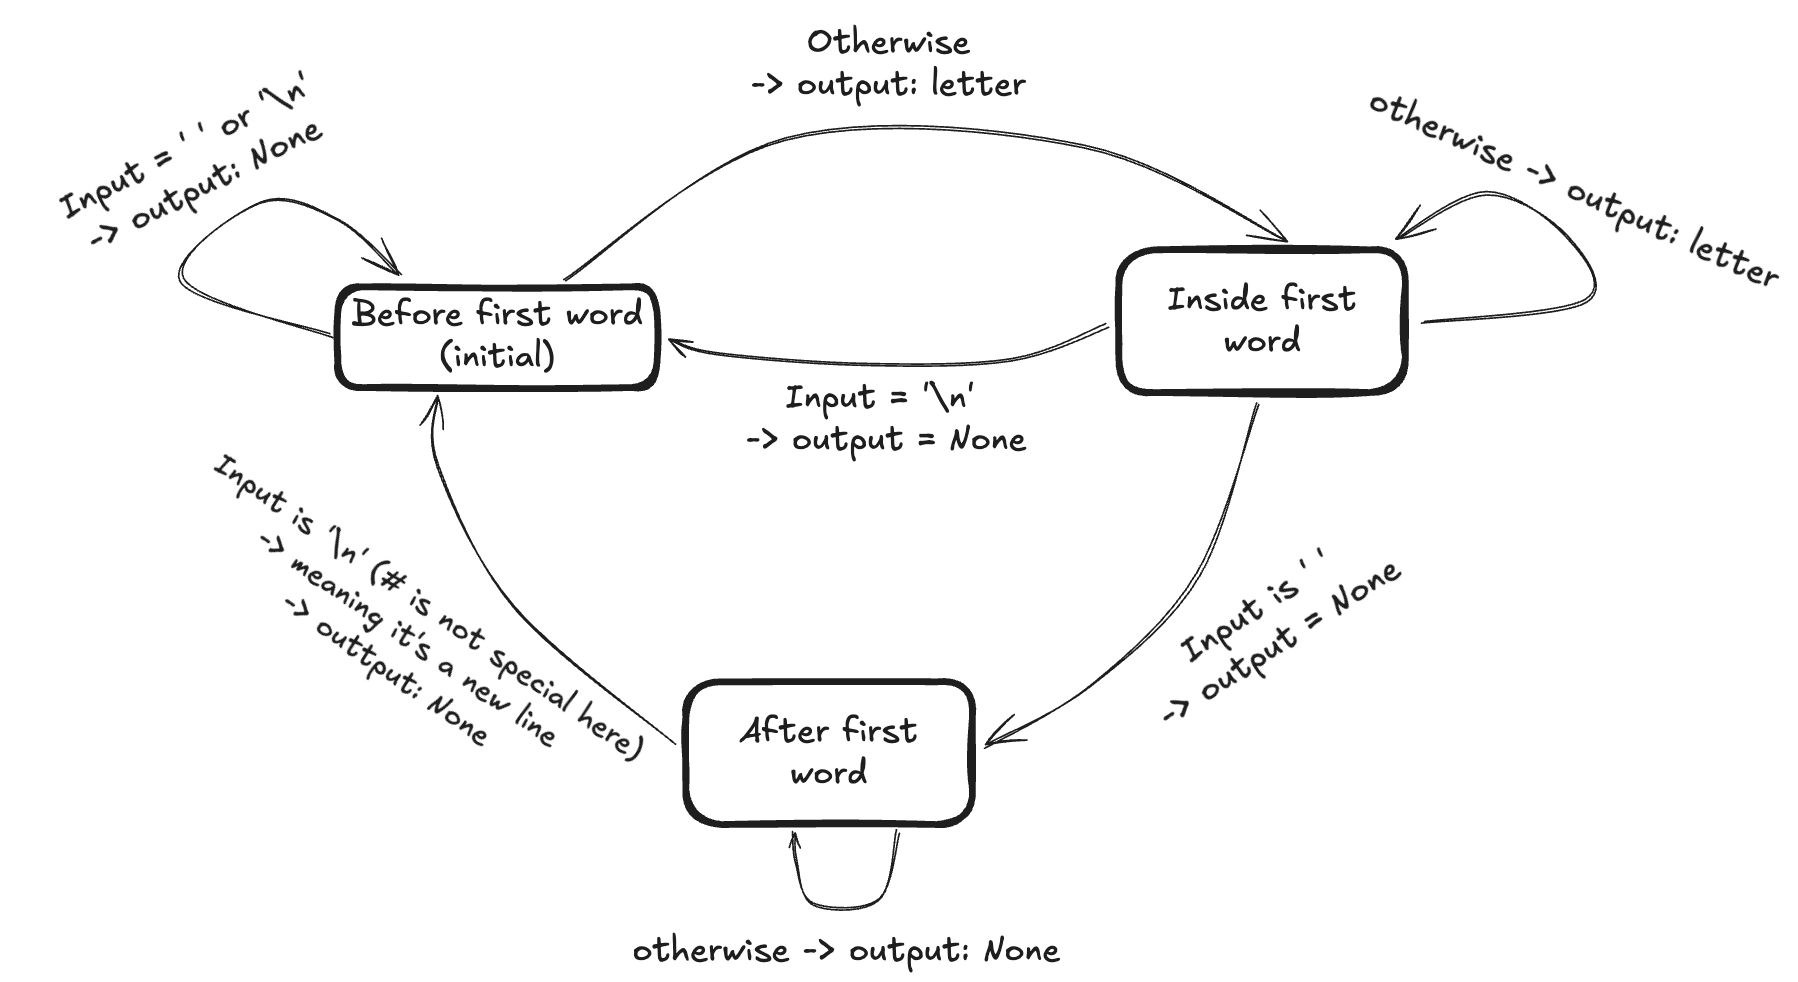

In [8]:
# show the state transition diagram I make
from IPython.display import Image, display
display(Image(filename='./week-08-diagrams/HW-CS2.png'))

In [9]:
class FirstWordSM(StateMachine):
  
    @property
    def start_state(self) -> str:
        return "Before first word"
  
    def get_next_values(self, state: str, inp: str) -> tuple[str, Optional[str]]:
        if state == "Before first word":
            if inp == ' ' or inp == '\n':
                next_state = "Before first word"
                output = None
            else:
                next_state = "Inside first word"
                output = inp
        
        if state == "Inside first word":
            if inp == ' ':
                next_state = "After first word"
                output = None
            elif inp == '\n':
                next_state = "Before first word"
                output = None
            else:
                next_state = "Inside first word"
                output = inp
        
        if state == "After first word":
            if inp == '\n':
                next_state = "Before first word"
                output = None
            else:
                next_state = "After first word"
                output = None
        
        return next_state, output

In [10]:
inpstr: str = "def func(x): # comment\n    return 1"
m: FirstWordSM = FirstWordSM()
out: list[Optional[str]] = m.transduce(inpstr)
print(out)
assert out == ["d", "e", "f", None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, "r", "e", "t", "u", "r", "n", None, None]


['d', 'e', 'f', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 'r', 'e', 't', 'u', 'r', 'n', None, None]


In [11]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW3.** *Robot:* Write a State Machine class that represent a robot. The dimension of the world and the robot initial position should be specified during the class instantiation. The robot can take in the following input:
- "left"
- "right"
- "up"
- "down"

The initial position of the robot is specified during the object instantiation and the input should modify the position of the robot. The robot position must not change if it exceed the boundary. At each step, the robot should output the updated position. 

In [12]:
class Position:
  
    def __init__(self, x: int=0, y: int=0) -> None:
        self.x: int = x
        self.y: int = y
  
    def __str__(self) -> str:
        return f"({self.x:}, {self.y:})"

class Dimension:

    def __init__(self, width: int=0, height: int=0) -> None:
        self.width: int = width
        self.height: int = height
  
    def __str__(self) -> str:
        return f"width: {self.width:}, height: {self.height:}"

In [13]:
class RobotSM(StateMachine):
    @property
    def start_state(self) -> Position:
        return self.__start_state
    
    @start_state.setter
    def start_state(self, value: Position) -> None:
        self.__start_state: Position = value

    def __init__(self, init_pos: Position, dimension: Dimension) -> None:
        self.world_dim: Dimension = dimension
        self.start_state = init_pos
  
    def get_next_values(self, state: Position, inp: str) -> tuple[Position, Position]:
        pos_x_before = state.x
        pos_y_before = state.y
        
        if inp == 'right':
            pos_x_after = pos_x_before + 1
            pos_y_after = pos_y_before
        elif inp == 'left':
            pos_x_after = pos_x_before - 1
            pos_y_after = pos_y_before
        elif inp == 'up':
            pos_x_after = pos_x_before
            pos_y_after = pos_y_before + 1
        elif inp == 'down':
            pos_x_after = pos_x_before
            pos_y_after = pos_y_before - 1
            
        # output does not matter here
        if pos_x_after <= self.world_dim.width and pos_y_after <= self.world_dim.height:
            output = Position(pos_x_after, pos_y_after)
            next_state = output
        else:
            output = Position(pos_x_before, pos_y_before)
            next_state = output
        
        return next_state, output

In [14]:
robot: RobotSM = RobotSM(Position(0, 0), Dimension(5, 5))
robot.start()
robot.transduce(["right", "right", "up", "up", "up", "left", "down"])
pos: Position = robot.state
assert pos.x == 1 and pos.y == 2

In [15]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW4.** *Search SM:* Write a function `sm_search` that takes in the following arguments:
- `sm_to_search`: is the State Machine instance to search. This argument is of the type `MapSM` as defined in CS4. You should use the `get_next_values()` of this State Machine instance to explore the next state in your search.
- `initial_state`: is the start state of the search. If it is not provided, it should be assigned to the `start_state` of sm_search. 
- `goal_test`: is a function that returns `True` if the argument is the end state of the search. If it is not provided, it should be eassigned to the `done` function of the state machine.

This function performs a **breadth-first-search** algorithm to explore the next states. 

The output is a `list` of `Step` instances from the `init_state` to the end state which is determined by the `goal_test` function.

This problem requires you to complete the following:
- `Queue` class from Problem Set 4 HW2.
- `MapSM` class in CS4.
- `SearchNode` and `Step` classes in CS5.

In [16]:
# Copy over the implementations of Queue from PS4 HW2
class Queue:
    def __init__(self) -> None:
        self.__items: list[Any] = []
    
    def enqueue(self, item: Any) -> None:
        self.__items.append(item)

    def dequeue(self) -> Any:
        if self.is_empty:
            return None
        return self.__items.pop(0)
    
    def peek(self) -> Any:
        if self.is_empty:
            return None
        return self.__items[0]

    @property
    def is_empty(self) -> bool:
        return len(self.__items) == 0

    @property
    def size(self) -> int:
        return len(self.__items)


In [17]:
from abc import abstractmethod

class StateSpaceSearch(StateMachine):
    
    @property
    @abstractmethod
    def statemap(self) -> dict:
        pass

    @property
    @abstractmethod
    def legal_inputs(self) -> set:
        pass

    @property
    def start_state(self) -> Any:
        return self.__start_state
    
    @start_state.setter
    def start_state(self, value: Any) -> None:
        self.__start_state = value
    
    def get_next_values(self, state: Any, inp: Any) -> tuple[Any, Any]:
        neighbors = self.statemap[state]
        
        if inp not in self.legal_inputs or inp >= len(neighbors):
            return self.get_next_values_invalid(state, inp)
        else:
            next_state = neighbors[inp]
            output = next_state
        
        return next_state, output

    def get_next_values_invalid(self, state: Any, inp: Any) -> tuple[Any, Any]:
        return state, 'invalid input' 

In [18]:
class MapSM(StateSpaceSearch):
        
    def __init__(self, start: str) -> None:
        self.start_state = start

    @property
    def statemap(self) -> dict[str, list[tuple[str, str]]]:
        return {"S": ["A", "B"],
        "A": ["S", "C", "D"],
        "B": ["S", "D", "E"],
        "C": ["A", "F"],
        "D": ["A", "B", "F", "H"],
        "E": ["B", "H"],
        "F": ["C", "D", "G"],
        "H": ["D", "E", "G"],
        "G": ["F", "H"]}

    @property
    def legal_inputs(self) -> set[int]:
        max_neighbor = max([len(item) for item in self.statemap.values()])
        
        # return a dict {} containing all valid inputs. e.g: 0, 1, 2, 3
        return set(range(max_neighbor))

In [19]:
# Copy over the implementations of Step and SearchNode from Cohort
class Step:
    def __init__(self, action: Optional[int], state: str) -> None:
        self.action: Optional[int] = action
        self.state: str = state
    
    def __eq__(self, other) -> bool:
        return self.action == other.action and self.state == other.state
  
    def __str__(self) -> str:
        return f"action: {self.action:}, state: {self.state:}"

class SearchNode:
    def __init__(self, action: Optional[int], state: str, parent: Optional[SearchNode]) -> None:
        self.state: str = state
        self.action: Optional[int] = action
        self.parent: Optional[SearchNode] = parent
  
    def path(self) -> list[Step]:
        # parent of a node is a node from which we can reach to the desired node
        
        # Base case
        if self.parent is None:
            return [Step(self.action, self.state)]
        # Recursive case
        else:
            # e.g: path from S to D: Path from S to parent of D + Step from parent of D to D
            return self.parent.path() + [(Step(self.action, self.state))]
  
    def in_path(self, state: str) -> bool:
        # the point of the func: before add a state as a NEW searchnode to explore
        # first check if the state (node) is already in our path (meaning we already discover)
        # then will skip the state, if it's already in the path
        
        # Base case
        if self.state == state:
            return True
        elif self.parent is None: # curr_state is not target, and curr_state has no parent
            return False
        else:
            # recursive case: walk up inside the path to check if the state already exists
            return self.parent.in_path(state)
  
    def __eq__(self, other) -> bool:
        if self is None and other is None:
            return True
        elif self is None:
            return False
        elif other is None:
            return False
        else:
            return self.state == other.state and self.parent == other.parent and \
                   self.action == other.action

In [20]:
def sm_search(sm_to_search: StateSpaceSearch, initial_state: Optional[str]=None, goal_test: Optional[Callable]=None) -> Optional[list[Step]]:
    # check if initial_state is provided
    # if it is, use it
    # otherwise, get the start state of sm_to_search
    if initial_state is None:
        # replace None to take the start state of sm_to_search
        init_state: str = sm_to_search.start_state
    else:
        init_state = initial_state
  
    # check if goal_test is provided
    # if it is, use it
    # otherwise, use the done method as the goal function
    # taken from sm_to_search
    if goal_test is None:
        goal_func: Callable = sm_to_search.done
    else:
        goal_func = goal_test
  
    # create a Queue instance to store the node to explore
    # replace the None below
    agenda = Queue()
  
    # create a list to keep track which child state have been explored
    new_child_state: list[str] = []

    # if the initial state is the goal state, 
    # then we are done and exit
    if goal_func(init_state):
        return [Step(None, init_state)]
  
    # otherwise, add the current node into the agenda 
    agenda.enqueue(SearchNode(None, init_state, None))
    
    # explore as long as the Queue is not empty
    while not agenda.is_empty:
        
        # replace None to take out the parent from the Queue
        parent = agenda.dequeue()
        
        
        # get all the legal input values
        actions: set[int] = sm_to_search.legal_inputs
        
        #iterate over all legal inputs
        for a in actions:
            # if the action is valid,
            #   get the next possible state using the current action
            #   call get_next_values to get the next state
            # otherwise, skip to the next action
            #
            # replace the None below and add if-else statement
            new_s, output = sm_to_search.get_next_values(parent.state, a)
            if output == 'invalid input':
                continue
            
            # create a new search node from the new_s
            # replace the None below
            new_n: SearchNode = SearchNode(a, new_s, parent)
            
            # if the new state is the goal state, then we exit and return the path
            if goal_func(new_s):
                return new_n.path()
            
            # if the new state is already in the list of new child state, ignore it
            elif new_s in new_child_state:
                pass
            
            # otherwise, add the new state into the list
            # and the new node into the Queue
            else:
                # step 1. add the new state into the new_child_state
                new_child_state.append(new_s)
                
                # step 2. add the new node into the Queue
                agenda.enqueue(new_n)
    return None

In [21]:
mapSM: MapSM = MapSM("S")
ans: Optional[list[Step]] = sm_search(mapSM , "S" , lambda s: s=="H" )
assert ans is not None
steps: list[tuple[Optional[int], str]] = [(step.action, step.state) for step in ans]
assert steps == [(None, "S"), (0, "A"), (2, "D"), (3, "H")]
for step in ans:
    print(step)

action: None, state: S
action: 0, state: A
action: 2, state: D
action: 3, state: H


In [22]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###